In [85]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin


In [86]:
TARGET_COLUMN = 'is_increment_24hs'

In [87]:
import pandas as pd

raw_df = pd.read_csv('data.csv')
raw_df.head()

,date,text,favorites,retweets,Toxic,Insult,Profanity,Derogatory,Sexual,"Death, Harm & Tragedy",...,Illicit Drugs,War & Conflict,Politics,Finance,Legal,btc_tweet_day,btc_24h_after,btc_48h_after,btc_delta_24h,btc_delta_48h
0,2020-03-03 01:34:00,I was thrilled to be back in the Great city of...,73748,17404,0.014622,0.010394,0.002904,0.003574,0.002435,0.059701,...,0.036585,0.472222,0.867769,0.079710,0.435185,8753.01,8700.00,9085.48,-53.01,332.47
1,2020-01-17 03:22:00,RT @CBS_Herridge: READ: Letter to surveillance...,0,7396,0.050346,0.050961,0.023985,0.008934,0.010127,0.085399,...,0.294118,0.350000,0.680934,0.081967,0.948357,8850.83,8903.26,8631.95,52.43,-218.88
2,2020-09-12 20:10:00,The Unsolicited Mail In Ballot Scam is a major...,80527,23502,0.258527,0.112138,0.058611,0.043741,0.015008,0.082609,...,0.700000,0.058824,0.937500,0.515901,0.858108,10359.99,10280.14,10698.03,-79.85,338.04
3,2020-01-17 13:13:00,RT @MZHemingway: Very friendly telling of even...,0,9081,0.018771,0.012035,0.004276,0.003942,0.002470,0.207207,...,0.057377,0.375000,0.912500,0.079710,0.333333,8850.83,8903.26,8631.95,52.43,-218.88
4,2020-01-17 00:11:00,RT @WhiteHouse: President @realDonaldTrump ann...,0,25048,0.016713,0.011194,0.004276,0.005187,0.002435,0.073482,...,0.057377,0.141892,0.969512,0.102302,0.948357,8850.83,8903.26,8631.95,52.43,-218.88


In [88]:
raw_df.columns
print(raw_df["date"].dtypes)
print(raw_df.shape)

object
(22451, 25)


In [89]:
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_drop=None):
        self.columns_to_drop = columns_to_drop or []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=self.columns_to_drop)

In [90]:
class GenerateTarget(BaseEstimator, TransformerMixin):
    """
    Transformer that generates a binary target column (`target_movement`)
    from the numeric feature `btc_delta_24h_pct`.
    
    Returns the same DataFrame with the new column appended.
    """

    def fit(self, X, y=None):
        
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        
        X = X.copy()

        X[TARGET_COLUMN] = (X['btc_delta_24h'] > 0).astype(int)

        return X


In [91]:
import re
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class NormalizeData(BaseEstimator, TransformerMixin):
    """Transformer that normalizes column names to snake_case."""

    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    @staticmethod
    def to_snake_case(name):
        """Convert a string to snake_case."""
        s1 = re.sub(r'(.)([A-Z][a-z]+)', r'\1_\2', name)
        s2 = re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', s1)
        s3 = re.sub(r'[-\s]+', '_', s2)
        s4 = re.sub(r'_+', '_', s3)
        return s4.strip('_').lower()

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df.columns = [self.to_snake_case(col) for col in df.columns]
        return df


In [92]:
import numpy as np

class ManualFeatureEngineering(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self
        

    def extract_hour(self, df):
        df["tmp_date"] = pd.to_datetime(df["date"], utc=True, errors="coerce")
        df["hour"] = df["tmp_date"].dt.hour
        df["normalized_hour"] = (df["hour"] - 6) % 24
        df.drop(columns=["tmp_date"], inplace=True)
        return df

    def extract_day_of_week(self, df):
        date_parsed = pd.to_datetime(df["date"], utc=True, errors="coerce")
        df["day_name"] = date_parsed.dt.day_name().astype("category")
        df["day_of_week"] = date_parsed.dt.dayofweek
        df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
        return df

    def transform(self, df):
        
        df['btc_delta_24h_pct'] = df['btc_delta_24h'] / df['btc_tweet_day']
        df['btc_delta_48h_pct'] = df['btc_delta_48h'] / df['btc_tweet_day']


        df = self.extract_hour(df)
        df = self.extract_day_of_week(df)

        # Feature que junta otras de google
        
        # Otra feature mas

        return df

In [93]:
from sklearn.compose import make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline, FeatureUnion

numeric_pipeline = FeatureUnion([
    ("scaled", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler())
    ])),
    ("pca", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
        ("pca", PCA(n_components=2))
    ]))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

column_transformer = ColumnTransformer([
    ('num', numeric_pipeline, make_column_selector(dtype_include=np.number)),
    ('cat', categorical_pipeline, make_column_selector(dtype_exclude=np.number))
])

# === Global preprocessing pipeline ===
preprocessor = Pipeline([
    ("feature_engineering", ManualFeatureEngineering()),
    ("drop_columns", DropColumns(columns_to_drop=["date","text",
        'btc_24h_after', 'btc_48h_after', 'btc_delta_24h', 'btc_delta_48h', "btc_delta_48h_pct", "btc_delta_24h_pct"
    ])),
    ("column_transformer", column_transformer),
])

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

data_prep_pipeline = Pipeline([
    ("generate_target", GenerateTarget()),
])

df_prepared = data_prep_pipeline.fit_transform(raw_df)

y = df_prepared[TARGET_COLUMN]
X = df_prepared.drop(columns=[TARGET_COLUMN])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [95]:
from sklearn.model_selection import KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42)


In [96]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV

# Pipeline
rf_cv_pca_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    # ("drop_columns", DropColumns(columns_to_drop=["date"])),
    ("model", RandomForestClassifier
    (
        class_weight='balanced',
        random_state=42
    ))
])

# Grilla de parámetros
param_grid_rf = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10]
}

grid_rf = GridSearchCV(
    rf_cv_pca_pipeline,
    param_grid=param_grid_rf,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [50, 100, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,steps,"[('feature_engineering', ...), ('drop_columns', ...), ...]"


In [97]:
# Get the fitted preprocessor from the best estimator
preprocessor = grid_rf.best_estimator_.named_steps["preprocessing"]

# Transform your training data
X_processed = preprocessor.transform(X_train)

print("✅ Processed shape:", X_processed.shape)
ct = preprocessor.named_steps["column_transformer"]
feature_names = ct.get_feature_names_out()

print("🔹 Total features:", len(feature_names))
print("🔹 First 20 feature names:", feature_names[:100])

✅ Processed shape: (17960, 32)
🔹 Total features: 32
🔹 First 20 feature names: ['num__scaled__favorites' 'num__scaled__retweets' 'num__scaled__Toxic'
 'num__scaled__Insult' 'num__scaled__Profanity' 'num__scaled__Derogatory'
 'num__scaled__Sexual' 'num__scaled__Death, Harm & Tragedy'
 'num__scaled__Violent' 'num__scaled__Firearms & Weapons'
 'num__scaled__Public Safety' 'num__scaled__Health'
 'num__scaled__Religion & Belief' 'num__scaled__Illicit Drugs'
 'num__scaled__War & Conflict' 'num__scaled__Politics'
 'num__scaled__Finance' 'num__scaled__Legal' 'num__scaled__btc_tweet_day'
 'num__scaled__hour' 'num__scaled__normalized_hour'
 'num__scaled__day_of_week' 'num__scaled__is_weekend' 'num__pca__pca0'
 'num__pca__pca1' 'cat__day_name_Friday' 'cat__day_name_Monday'
 'cat__day_name_Saturday' 'cat__day_name_Sunday' 'cat__day_name_Thursday'
 'cat__day_name_Tuesday' 'cat__day_name_Wednesday']


In [98]:
from matplotlib.pyplot import figure, title
from sklearn.metrics import classification_report, confusion_matrix
from pandas import Series

print("Best parameters (Random Forest):")
print(grid_rf.best_params_)

def evaluar_modelo(nombre, y_true, y_pred):
    print(f"\n🔎 {nombre}\n")
    print("Classification report:")
    print(classification_report(y_true, y_pred, digits=3))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

y_pred_logreg_grid = grid_rf.predict(X_test)

evaluar_modelo("Random Forest", y_test, y_pred_logreg_grid)



Best parameters (Random Forest):
{'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}

🔎 Random Forest

Classification report:
              precision    recall  f1-score   support

           0      0.757     0.646     0.697      2089
           1      0.727     0.820     0.770      2402

    accuracy                          0.739      4491
   macro avg      0.742     0.733     0.734      4491
weighted avg      0.741     0.739     0.736      4491

Confusion matrix:
[[1349  740]
 [ 433 1969]]


## XGBoost 

In [99]:
# XGBoost requires values encoded as a map with numpy numbers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Class mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}


In [100]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)


pipeline_xgb = ImbPipeline([
    ("feature_engineer", ManualFeatureEngineering()),
    ("drop_columns", DropColumns(columns_to_drop=["date","text",
        'btc_24h_after', 'btc_48h_after', 'btc_delta_24h', 'btc_delta_48h', "btc_delta_48h_pct", "btc_delta_24h_pct"
    ])),
    ("column_transformer", column_transformer),
    ("model", xgb_model)
])

param_grid_xgb = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [4, 6, 8],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    pipeline_xgb,
    param_grid=param_grid_xgb,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)


grid_xgb.fit(X_train, y_train_encoded)

y_pred_xgb_grid = grid_xgb.predict(X_test)
evaluar_modelo("XGBoost", y_test_encoded, y_pred_xgb_grid)


🔎 XGBoost

Classification report:
              precision    recall  f1-score   support

           0      0.903     0.890     0.897      2089
           1      0.906     0.917     0.911      2402

    accuracy                          0.904      4491
   macro avg      0.904     0.904     0.904      4491
weighted avg      0.904     0.904     0.904      4491

Confusion matrix:
[[1860  229]
 [ 200 2202]]


## LightGBM

In [101]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
import time

lgb_model = LGBMClassifier(
    objective="binary",
    metric="binary_logloss",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    boosting_type='gbdt',
    num_leaves=31,
    max_depth=6,
    learning_rate=0.1,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    reg_alpha=0.1,
    reg_lambda=0.1
)

pipeline_lgb = ImbPipeline([
    ("feature_engineer", ManualFeatureEngineering()),
    ("drop_columns", DropColumns(columns_to_drop=["date","text",
        'btc_24h_after', 'btc_48h_after', 'btc_delta_24h', 'btc_delta_48h', "btc_delta_48h_pct", "btc_delta_24h_pct"
    ])),
    ("column_transformer", column_transformer),
    ("model", lgb_model)
])

param_grid_lgb = {
    "model__n_estimators": [100, 150], 
    "model__learning_rate": [0.1, 0.12], 
    "model__num_leaves": [31, 50], 
}

grid_lgb = RandomizedSearchCV(
    pipeline_lgb,
    param_distributions=param_grid_lgb,
    n_iter=8,  
    scoring="f1",
    cv=3, 
    n_jobs=-1,
    random_state=42,
    verbose=1
)

start_time = time.time()

grid_lgb.fit(X_train, y_train_encoded)

end_time = time.time()
training_time = end_time - start_time

print("parametros: ", grid_lgb.best_params_)

y_pred_lgb_grid = grid_lgb.predict(X_test)
evaluar_modelo("LightGBM", y_test_encoded, y_pred_lgb_grid)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
parametros:  {'model__num_leaves': 31, 'model__n_estimators': 150, 'model__learning_rate': 0.12}

🔎 LightGBM

Classification report:
              precision    recall  f1-score   support

           0      0.841     0.820     0.830      2089
           1      0.846     0.865     0.856      2402

    accuracy                          0.844      4491
   macro avg      0.844     0.842     0.843      4491
weighted avg      0.844     0.844     0.844      4491

Confusion matrix:
[[1712  377]
 [ 324 2078]]


c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Comparación de Modelos


       Modelo  Accuracy  Precision  Recall  F1-Score
Random Forest    0.7388     0.7268  0.8197    0.7705
      XGBoost    0.9045     0.9058  0.9167    0.9112
     LightGBM    0.8439     0.8464  0.8651    0.8557

🏆 Best model: XGBoost
   F1-Score: 0.9112
   Accuracy: 0.9045


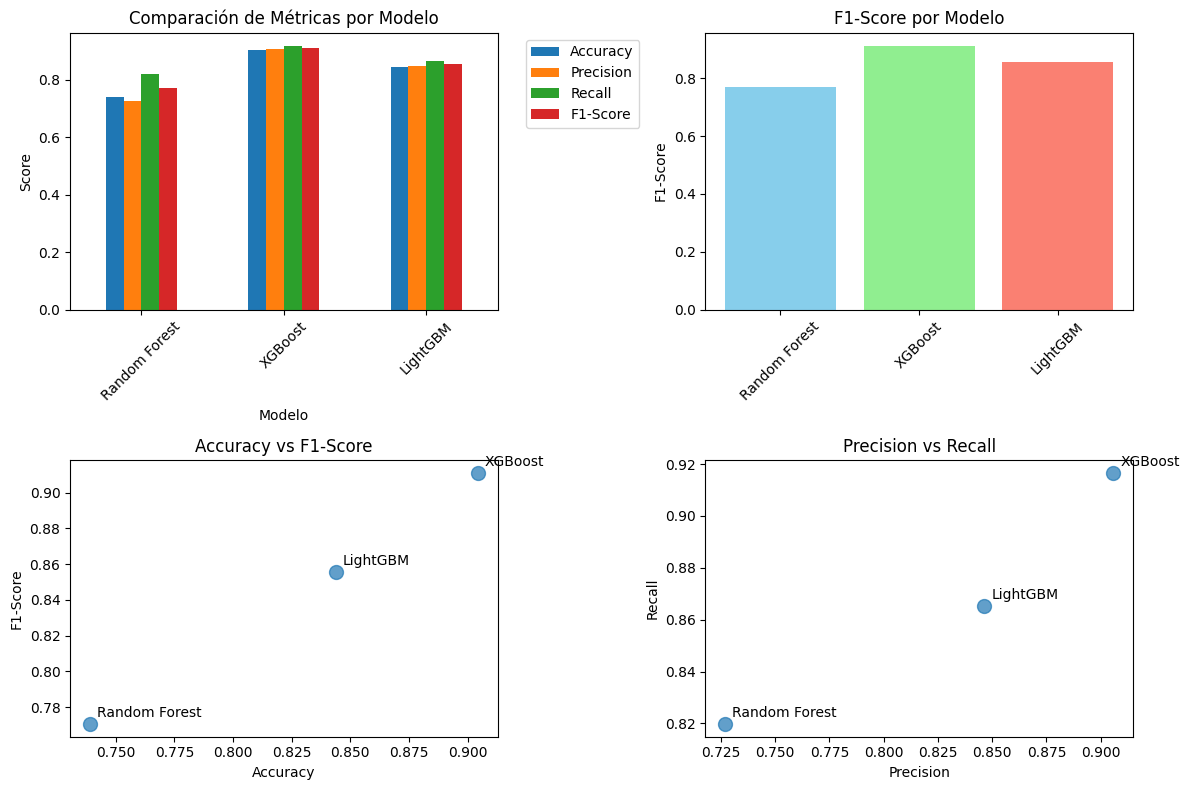

In [102]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def calcular_metricas(y_true, y_pred, nombre_modelo):
    return {
        'Modelo': nombre_modelo,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

metricas_modelos = []

metricas_modelos.append(calcular_metricas(y_test, y_pred_logreg_grid, "Random Forest"))

metricas_modelos.append(calcular_metricas(y_test_encoded, y_pred_xgb_grid, "XGBoost"))

metricas_modelos.append(calcular_metricas(y_test_encoded, y_pred_lgb_grid, "LightGBM"))


df_comparacion = pd.DataFrame(metricas_modelos)

for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    df_comparacion[col] = df_comparacion[col].round(4)

print(df_comparacion.to_string(index=False))

mejor_modelo = df_comparacion.loc[df_comparacion['F1-Score'].idxmax()]
print(f"\n🏆 Best model: {mejor_modelo['Modelo']}")
print(f"   F1-Score: {mejor_modelo['F1-Score']:.4f}")
print(f"   Accuracy: {mejor_modelo['Accuracy']:.4f}")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
metricas_principales = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
df_plot = df_comparacion.set_index('Modelo')[metricas_principales]
df_plot.plot(kind='bar', ax=plt.gca())
plt.title('Comparación de Métricas por Modelo')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.subplot(2, 2, 2)
plt.bar(df_comparacion['Modelo'], df_comparacion['F1-Score'], color=['skyblue', 'lightgreen', 'salmon'])
plt.title('F1-Score por Modelo')
plt.ylabel('F1-Score')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
plt.scatter(df_comparacion['Accuracy'], df_comparacion['F1-Score'], s=100, alpha=0.7)
for i, modelo in enumerate(df_comparacion['Modelo']):
    plt.annotate(modelo, (df_comparacion['Accuracy'].iloc[i], df_comparacion['F1-Score'].iloc[i]), 
                xytext=(5, 5), textcoords='offset points')
plt.xlabel('Accuracy')
plt.ylabel('F1-Score')
plt.title('Accuracy vs F1-Score')

plt.subplot(2, 2, 4)
plt.scatter(df_comparacion['Precision'], df_comparacion['Recall'], s=100, alpha=0.7)
for i, modelo in enumerate(df_comparacion['Modelo']):
    plt.annotate(modelo, (df_comparacion['Precision'].iloc[i], df_comparacion['Recall'].iloc[i]), 
                xytext=(5, 5), textcoords='offset points')
plt.xlabel('Precision')
plt.ylabel('Recall')
plt.title('Precision vs Recall')

plt.tight_layout()
plt.show()


## Feature Engineering con variables compuestas


In [103]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

class ExtraFeatureEng(BaseEstimator, TransformerMixin):
    """
    feature engineering con variables compuestas:
    -Scores compuestos por categoría
    -Score de impacto total
    -Análisis de correlación con variables combinadas
    -Features de clustering
    -Features de interacción
    """
    
    def __init__(self):
        self.variable_groups = {
            'toxicidad': ['toxic', 'insult', 'profanity', 'derogatory'],
            'violencia': ['death,_harm_&_tragedy', 'violent', 'firearms_&_weapons', 'public_safety'],
            'temas_sensibles': ['sexual', 'health', 'religion_&_belief', 'illicit_drugs'],
            'contexto_politico': ['politics', 'war_&_conflict', 'legal'],
            'finanzas': ['finance']
        }
        
        self.weights = {
            'toxic': 1.5,
            'insult': 1.2,
            'profanity': 1.1,
            'derogatory': 1.3,
            'sexual': 1.0,
            'death,_harm_&_tragedy': 2.0,
            'violent': 1.8,
            'firearms_&_weapons': 1.7,
            'public_safety': 1.6,
            'health': 1.0,
            'religion_&_belief': 1.2,
            'illicit_drugs': 1.4,
            'war_&_conflict': 1.9,
            'politics': 1.5,

            'legal': 1.3
        }
        
        self.scaler = StandardScaler()
        self.kmeans = KMeans(n_clusters=5, random_state=42)
        
    def fit(self, X, y=None):
        return self
    
    def create_composite_scores(self, df):
        """
        Crear scores compuestos por categoría
        """
        scores_df = df.copy()
        
        for group_name, variables in self.variable_groups.items():

            existing_vars = [var for var in variables if var in df.columns]
            
            if existing_vars:
    
                scores_df[f'{group_name}_score'] = df[existing_vars].sum(axis=1)
                
    
                scores_df[f'{group_name}_normalized'] = df[existing_vars].mean(axis=1)
                
    
                scores_df[f'{group_name}_max'] = df[existing_vars].max(axis=1)
                
    
                scores_df[f'{group_name}_std'] = df[existing_vars].std(axis=1)
                
    
                scores_df[f'{group_name}_range'] = df[existing_vars].max(axis=1) - df[existing_vars].min(axis=1)
        
        return scores_df
    
    def create_total_impact_score(self, df):
        """
        Crear score de impacto total
        """
        categorical_vars = [
            'toxic', 'insult', 'profanity', 'derogatory', 'sexual', 
            'death,_harm_&_tragedy', 'violent', 'firearms_&_weapons', 
            'public_safety', 'health', 'religion_&_belief', 'illicit_drugs', 
            'war_&_conflict', 'politics', 'finance', 'legal'
        ]
        
        existing_vars = [var for var in categorical_vars if var in df.columns]
        
        df['total_impact_score'] = df[existing_vars].sum(axis=1)
        
        weighted_score = 0
        for var in existing_vars:
            weight = self.weights.get(var, 1.0)
            weighted_score += df[var] * weight
        
        df['total_impact_weighted'] = weighted_score
        
        df['max_intensity'] = df[existing_vars].max(axis=1)
        
        df['diversity_score'] = (df[existing_vars] > 0).sum(axis=1)
        
        df['concentration_score'] = df['diversity_score'] / len(existing_vars)
        
        df['entropy_score'] = -np.sum(df[existing_vars] * np.log(df[existing_vars] + 1e-8), axis=1)
        
        return df
    
    def create_interaction_features(self, df):
        """
        Crear features de interacción
        """
        if 'toxicidad_score' in df.columns and 'violencia_score' in df.columns:
            df['toxicidad_violencia_interaction'] = df['toxicidad_score'] * df['violencia_score']
        
        if 'finanzas_score' in df.columns and 'contexto_politico_score' in df.columns:
            df['finanzas_politica_interaction'] = df['finanzas_score'] * df['contexto_politico_score']
        
        if 'hour' in df.columns:
            if 'total_impact_score' in df.columns:
                df['impact_hour_interaction'] = df['total_impact_score'] * df['hour']
            
            if 'diversity_score' in df.columns:
                df['diversity_hour_interaction'] = df['diversity_score'] * df['hour']
        
        if 'favorites' in df.columns and 'retweets' in df.columns:
            df['engagement_score'] = df['favorites'] + df['retweets']
            df['engagement_ratio'] = df['favorites'] / (df['retweets'] + 1)
            
            if 'total_impact_score' in df.columns:
                df['impact_engagement_interaction'] = df['total_impact_score'] * df['engagement_score']
        
        return df
    
    def create_clustering_features(self, df):
        """
        Crear features de clustering
        """
        clustering_vars = [
            'toxic', 'insult', 'profanity', 'derogatory', 'sexual',
            'death,_harm_&_tragedy', 'violent', 'firearms_&_weapons',
            'public_safety', 'health', 'religion_&_belief', 'illicit_drugs',
            'war_&_conflict', 'politics', 'finance', 'legal'
        ]
        
        existing_clustering_vars = [var for var in clustering_vars if var in df.columns]
        
        if len(existing_clustering_vars) > 0:

            clustering_data = df[existing_clustering_vars].fillna(0)
            clustering_data_scaled = self.scaler.fit_transform(clustering_data)
            

            clusters = self.kmeans.fit_predict(clustering_data_scaled)
            df['sentiment_cluster'] = clusters
            

            df['cluster_distance'] = np.min(self.kmeans.transform(clustering_data_scaled), axis=1)
            

            for i in range(5):
                df[f'cluster_{i}'] = (df['sentiment_cluster'] == i).astype(int)
        
        return df
    
    def create_temporal_features(self, df):
        """
        Crear features temporales avanzadas
        """
        if 'date' in df.columns:
            df['tmp_date'] = pd.to_datetime(df['date'], utc=True, errors="coerce")
            

            df['day_of_year'] = df['tmp_date'].dt.dayofyear
            df['week_of_year'] = df['tmp_date'].dt.isocalendar().week
            df['month'] = df['tmp_date'].dt.month
            df['quarter'] = df['tmp_date'].dt.quarter
            

            df['is_weekend'] = df['tmp_date'].dt.dayofweek.isin([5, 6]).astype(int)
            df['is_month_start'] = df['tmp_date'].dt.is_month_start.astype(int)
            df['is_month_end'] = df['tmp_date'].dt.is_month_end.astype(int)
            df['is_quarter_start'] = df['tmp_date'].dt.is_quarter_start.astype(int)
            df['is_quarter_end'] = df['tmp_date'].dt.is_quarter_end.astype(int)
            

            df['hour'] = df['tmp_date'].dt.hour
            df['is_business_hours'] = ((df['hour'] >= 9) & (df['hour'] <= 17)).astype(int)
            df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype(int)
            df['is_morning'] = ((df['hour'] >= 6) & (df['hour'] <= 12)).astype(int)
            df['is_afternoon'] = ((df['hour'] >= 12) & (df['hour'] <= 18)).astype(int)
            df['is_evening'] = ((df['hour'] >= 18) & (df['hour'] <= 22)).astype(int)
            
            df.drop(columns=['tmp_date'], inplace=True)
        
        return df
    
    def create_ratio_features(self, df):
        """
        Crear features de ratio y proporciones
        """
        if 'toxicidad_score' in df.columns and 'violencia_score' in df.columns:
            df['toxicidad_violencia_ratio'] = df['toxicidad_score'] / (df['violencia_score'] + 1)
        
        if 'finanzas_score' in df.columns and 'contexto_politico_score' in df.columns:
            df['finanzas_politica_ratio'] = df['finanzas_score'] / (df['contexto_politico_score'] + 1)
        
        if 'favorites' in df.columns and 'retweets' in df.columns:
            df['favorites_retweets_ratio'] = df['favorites'] / (df['retweets'] + 1)
            
            if 'total_impact_score' in df.columns:
                df['impact_per_favorite'] = df['total_impact_score'] / (df['favorites'] + 1)
                df['impact_per_retweet'] = df['total_impact_score'] / (df['retweets'] + 1)
        
        if 'total_impact_score' in df.columns and 'hour' in df.columns:
            df['impact_per_hour'] = df['total_impact_score'] / (df['hour'] + 1)
        
        return df
    
    def transform(self, df):
        """
        Aplicar todas las feature engineering
        """
        df = self.create_total_impact_score(df)
        
        df = self.create_interaction_features(df)
        
        df = self.create_clustering_features(df)
        
        df = self.create_temporal_features(df)
        
        df = self.create_ratio_features(df)
        
        new_features = [col for col in df.columns if any(suffix in col for suffix in 
                       ['_score', '_normalized', '_max', '_std', '_range', '_interaction', 
                        '_cluster', '_ratio', '_per_', 'is_', 'quarter', 'week_'])]
        
        print(f"\nnew: {len(new_features)}")
        
        return df


## Random forest con nuevas features

In [104]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

extra_fe_pipeline = Pipeline([
    ("extra_feature_engineering", ExtraFeatureEng()),
    ("drop_columns", DropColumns(columns_to_drop=["date", "text",
        'btc_24h_after', 'btc_48h_after', 'btc_delta_24h', 'btc_delta_48h', 
        "btc_delta_48h_pct", "btc_delta_24h_pct"
    ])),
    ("column_transformer", column_transformer),
    ("model", RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

param_grid_extra = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 15, 25],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

grid_extra = GridSearchCV(
    extra_fe_pipeline,
    param_grid=param_grid_extra,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_extra.fit(X_train, y_train)

print( grid_extra.best_params_)

y_pred_extra = grid_extra.predict(X_test)
evaluar_modelo("Random Forest + Extra Features", y_test, y_pred_extra)


Fitting 5 folds for each of 81 candidates, totalling 405 fits

new: 25


c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['max_intensity' 'concentration_score']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['max_intensity' 'concentration_score']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

new: 25

🔎 Random Forest + Extra Features

Classification report:
              precision    recall  f1-score   support

           0      0.947     0.906     0.926      2089
           1      0.921     0.956     0.938      2402

    accuracy                          0.933      4491
   macro avg      0.934     0.931     0.932      4491
weighted avg      0.933     0.933     0.933      4491

Confusion matrix:
[[1892  197]
 [ 105 2297]]


c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['max_intensity' 'concentration_score']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['max_intensity' 'concentration_score']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


## XGBoost con nuevas features

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)


pipeline_xgb = ImbPipeline([
    ("feature_engineer", ExtraFeatureEng()),
    ("drop_columns", DropColumns(columns_to_drop=["date","text",
        'btc_24h_after', 'btc_48h_after', 'btc_delta_24h', 'btc_delta_48h', "btc_delta_48h_pct", "btc_delta_24h_pct"
    ])),
    ("column_transformer", column_transformer),
    ("model", xgb_model)
])

param_grid_xgb = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [4, 6, 8],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    pipeline_xgb,
    param_grid=param_grid_xgb,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)


grid_xgb.fit(X_train, y_train_encoded)

y_pred_xgb_grid = grid_xgb.predict(X_test)
evaluar_modelo("XGBoost + Extra Features", y_test_encoded, y_pred_xgb_grid)


new: 25


c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['max_intensity' 'concentration_score']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['max_intensity' 'concentration_score']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(



new: 25

🔎 XGBoost

Classification report:
              precision    recall  f1-score   support

           0      0.990     0.991     0.990      2089
           1      0.992     0.991     0.992      2402

    accuracy                          0.991      4491
   macro avg      0.991     0.991     0.991      4491
weighted avg      0.991     0.991     0.991      4491

Confusion matrix:
[[2070   19]
 [  21 2381]]


c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['max_intensity' 'concentration_score']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['max_intensity' 'concentration_score']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


## LightGBM con nuevas features

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
import time

lgb_model = LGBMClassifier(
    objective="binary",
    metric="binary_logloss",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    boosting_type='gbdt',
    num_leaves=31,
    max_depth=6,
    learning_rate=0.1,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    reg_alpha=0.1,
    reg_lambda=0.1
)

pipeline_lgb = ImbPipeline([
    ("feature_engineer", ExtraFeatureEng()),
    ("drop_columns", DropColumns(columns_to_drop=["date","text",
        'btc_24h_after', 'btc_48h_after', 'btc_delta_24h', 'btc_delta_48h', "btc_delta_48h_pct", "btc_delta_24h_pct"
    ])),
    ("column_transformer", column_transformer),
    ("model", lgb_model)
])

param_grid_lgb = {
    "model__n_estimators": [100, 150], 
    "model__learning_rate": [0.1, 0.12], 
    "model__num_leaves": [31, 50], 
}

grid_lgb = RandomizedSearchCV(
    pipeline_lgb,
    param_distributions=param_grid_lgb,
    n_iter=8,  
    scoring="f1",
    cv=3, 
    n_jobs=-1,
    random_state=42,
    verbose=1
)

start_time = time.time()

grid_lgb.fit(X_train, y_train_encoded)

end_time = time.time()
training_time = end_time - start_time

print("parametros: ", grid_lgb.best_params_)

y_pred_lgb_grid = grid_lgb.predict(X_test)
evaluar_modelo("LightGBM + Extra Features", y_test_encoded, y_pred_lgb_grid)


Fitting 3 folds for each of 8 candidates, totalling 24 fits

new: 25


c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['max_intensity' 'concentration_score']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['max_intensity' 'concentration_score']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


parametros:  {'model__num_leaves': 50, 'model__n_estimators': 150, 'model__learning_rate': 0.12}

new: 25

🔎 LightGBM

Classification report:
              precision    recall  f1-score   support

           0      0.943     0.926     0.935      2089
           1      0.937     0.951     0.944      2402

    accuracy                          0.940      4491
   macro avg      0.940     0.939     0.939      4491
weighted avg      0.940     0.940     0.940      4491

Confusion matrix:
[[1935  154]
 [ 117 2285]]


c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['max_intensity' 'concentration_score']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['max_intensity' 'concentration_score']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
